In [1]:
from google.colab import drive
drive.mount('/content/drive/')

import os
%cd /content/drive/MyDrive/ECE232_Project4/

Mounted at /content/drive/
/content/drive/MyDrive/ECE232_Project4


#Question 2

In [2]:
!pip install python-igraph -q

import os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import igraph as ig
from sklearn.metrics.cluster import homogeneity_score, completeness_score

warnings.filterwarnings("ignore")
print("Libraries loaded successfully")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 47.6 MB/s eta 0:00:00
Libraries loaded successfully


Stocks loaded: 505
Returns matrix: 216 days x 505 stocks


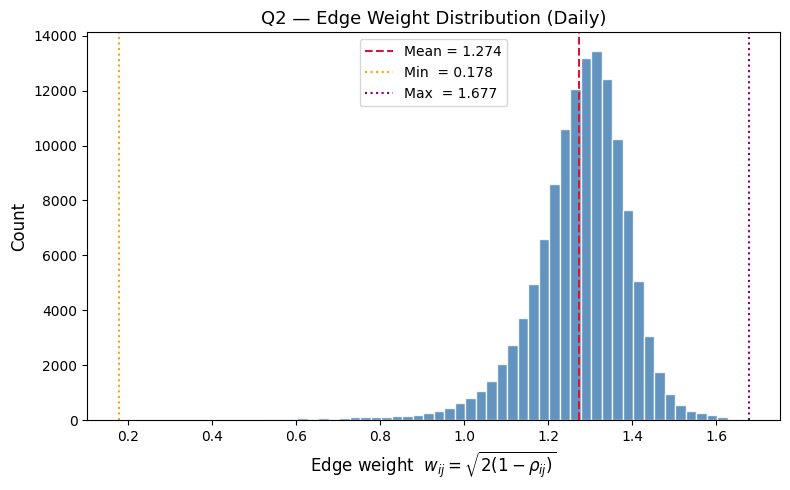

min=0.1779  max=1.6765  mean=1.2742  std=0.1199


In [3]:
import os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

# ── Load Data ──────────────────────────────────────────────────
sector_df  = pd.read_csv("finance_data/Name_sector.csv")
sector_map = dict(zip(sector_df["Symbol"].str.strip().str.upper(),
                      sector_df["Sector"].str.strip()))

stock_data = {}
for f in glob.glob("finance_data/data/*.csv"):
    ticker = os.path.splitext(os.path.basename(f))[0].upper()
    try:
        df = pd.read_csv(f, parse_dates=["Date"])
        stock_data[ticker] = df.sort_values("Date").reset_index(drop=True)
    except:
        pass

tickers = sorted([t for t in stock_data if t in sector_map])
print(f"Stocks loaded: {len(tickers)}")

# ── Compute Daily Log Returns ───────────────────────────────────
series = {}
for ticker in tickers:
    prices  = stock_data[ticker].set_index("Date")["Adj Close"].dropna()
    log_ret = np.log(prices / prices.shift(1)).dropna()
    series[ticker] = log_ret

daily_ret = pd.DataFrame(series).dropna()
print(f"Returns matrix: {daily_ret.shape[0]} days x {daily_ret.shape[1]} stocks")

# ── Correlation Matrix & Edge Weights ──────────────────────────
daily_corr = daily_ret.corr(method="pearson")
daily_w    = np.sqrt(2.0 * (1.0 - daily_corr))

# ── Q2: Plot Histogram ─────────────────────────────────────────
n    = len(daily_w)
vals = np.array([
    daily_w.iloc[i, j]
    for i in range(n)
    for j in range(i + 1, n)
    if not np.isnan(daily_w.iloc[i, j])
])

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(vals, bins=60, color="steelblue", edgecolor="white", alpha=0.85)
ax.axvline(vals.mean(), color="crimson", ls="--", label=f"Mean = {vals.mean():.3f}")
ax.axvline(vals.min(),  color="orange",  ls=":",  label=f"Min  = {vals.min():.3f}")
ax.axvline(vals.max(),  color="purple",  ls=":",  label=f"Max  = {vals.max():.3f}")
ax.set_xlabel(r"Edge weight  $w_{ij} = \sqrt{2(1 - \rho_{ij})}$", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title("Q2 — Edge Weight Distribution (Daily)", fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("q2_histogram_daily.png", dpi=150)
plt.show()

print(f"min={vals.min():.4f}  max={vals.max():.4f}  mean={vals.mean():.4f}  std={vals.std():.4f}")

#Question 3

MST: 505 nodes, 504 edges


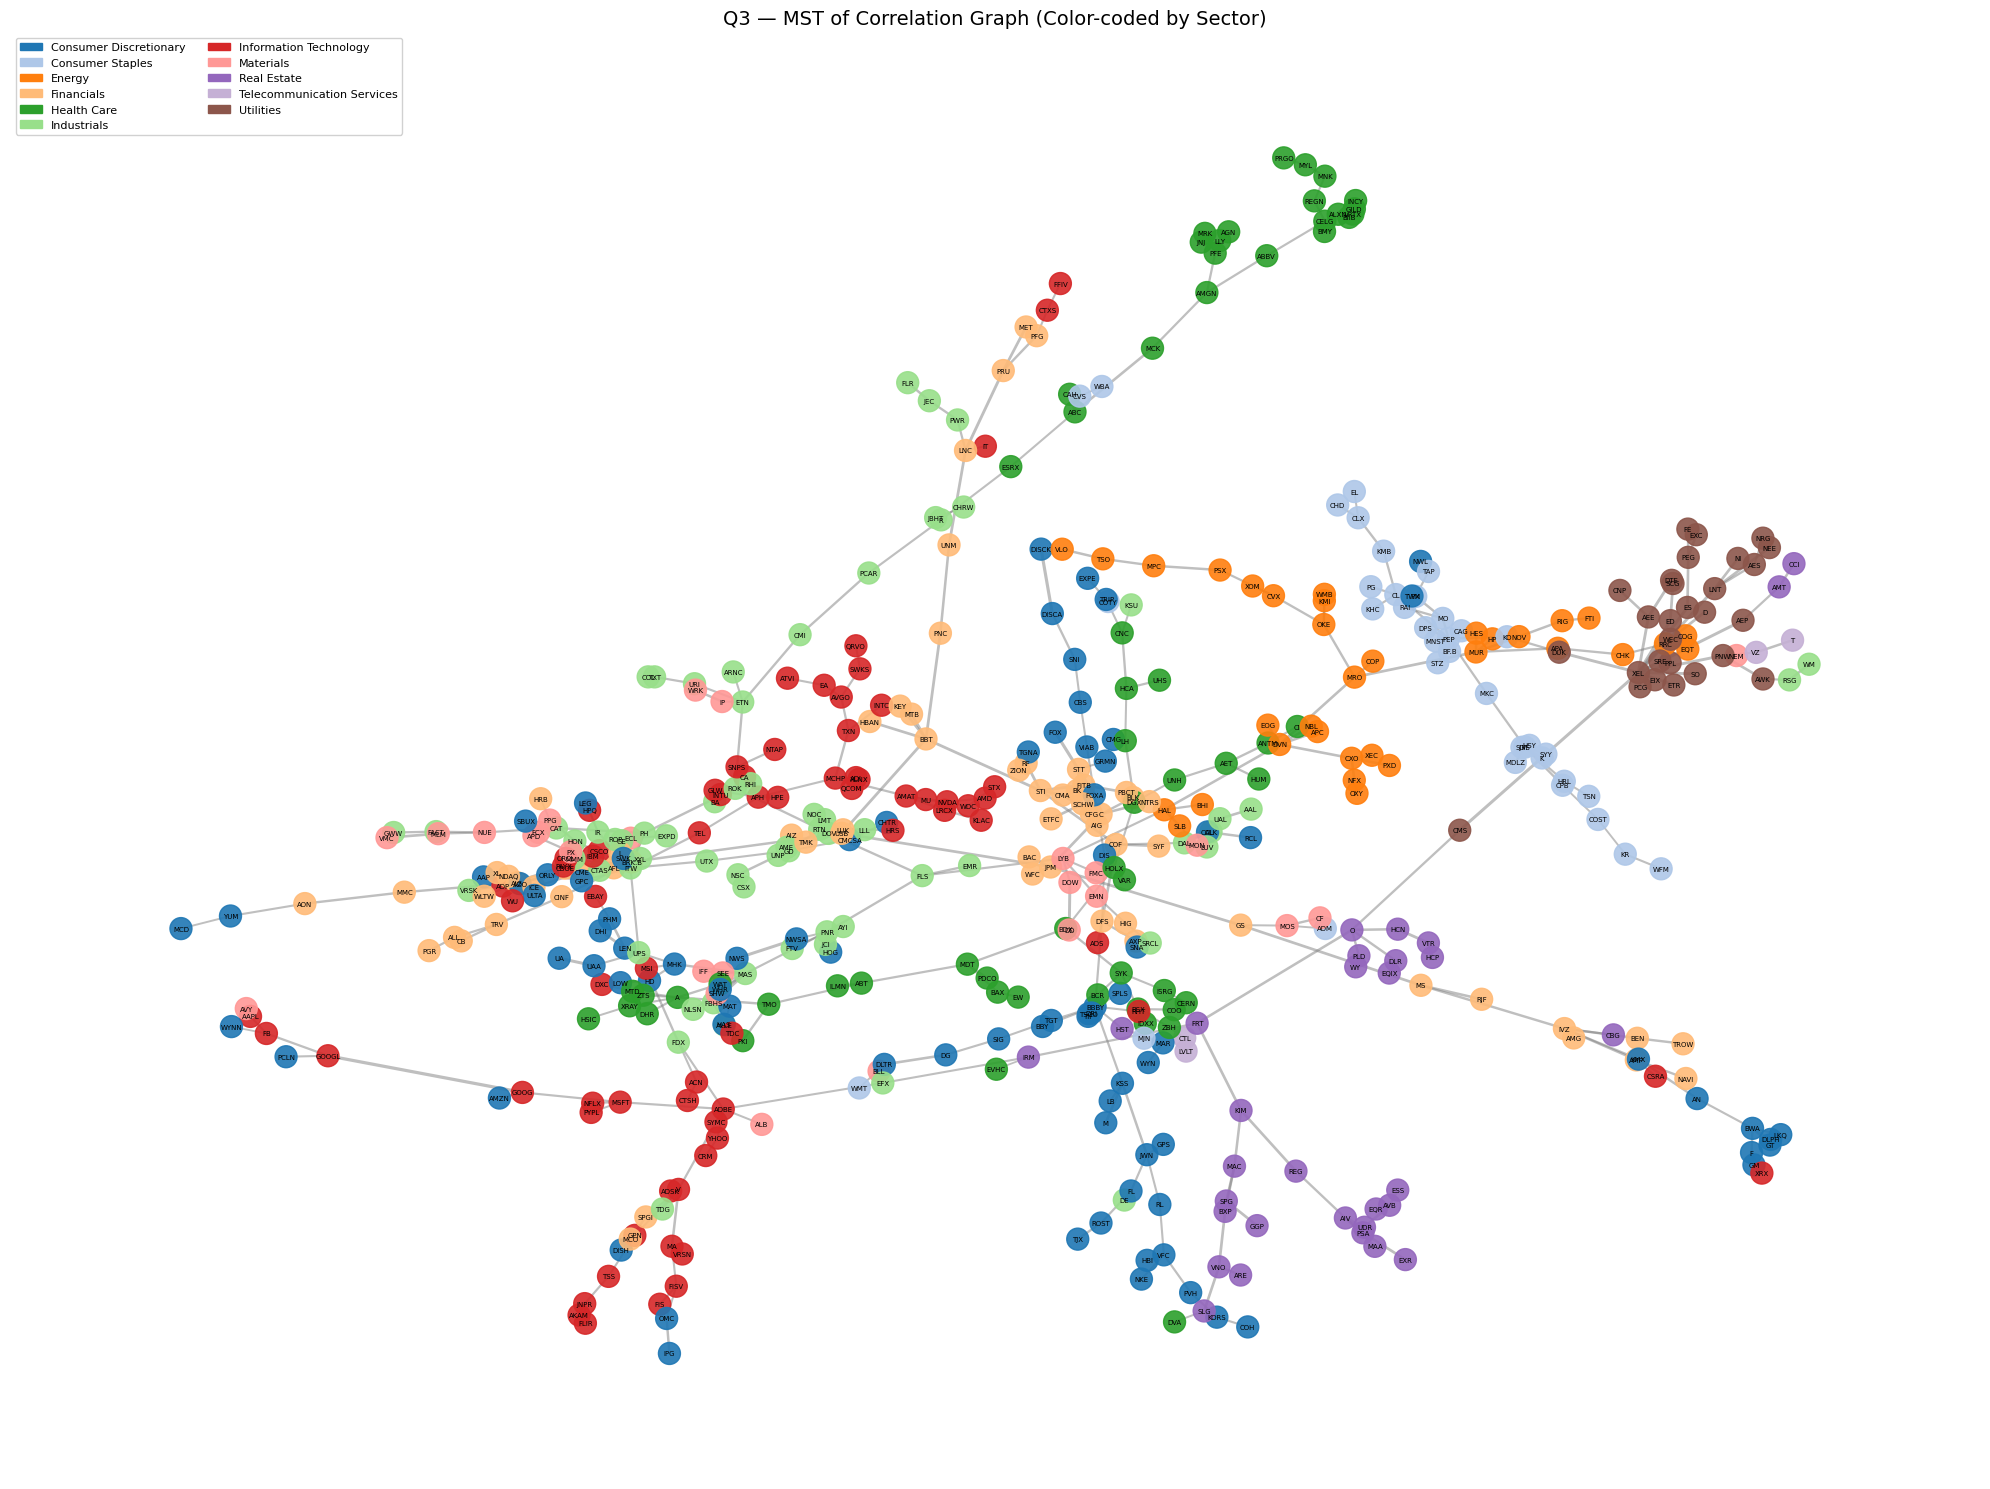

Highest degree node: XEL | Sector: Utilities | Degree: 15


In [4]:
import networkx as nx
import matplotlib.patches as mpatches

# ── Build Full Correlation Graph ────────────────────────────────
G = nx.Graph()
for t in tickers:
    G.add_node(t, sector=sector_map.get(t, "Unknown"))

cols = list(daily_w.columns)
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        w = daily_w.iloc[i, j]
        if not np.isnan(w):
            G.add_edge(cols[i], cols[j], weight=float(w))

# ── Extract MST ─────────────────────────────────────────────────
MST = nx.minimum_spanning_tree(G, weight="weight")
print(f"MST: {MST.number_of_nodes()} nodes, {MST.number_of_edges()} edges")

# ── Sector Color Palette ────────────────────────────────────────
sectors      = sorted(set(sector_map[t] for t in tickers))
palette      = plt.cm.tab20.colors
sector_color = {s: palette[i % 20] for i, s in enumerate(sectors)}

node_colors  = [sector_color[MST.nodes[n]["sector"]] for n in MST.nodes]
edge_weights = [MST[u][v]["weight"] for u, v in MST.edges()]

# ── Plot ────────────────────────────────────────────────────────
pos = nx.spring_layout(MST, seed=42, k=2.0)

fig, ax = plt.subplots(figsize=(20, 15))
nx.draw_networkx_edges(MST, pos, ax=ax, edge_color="gray", alpha=0.5,
                        width=[max(0.3, 2.5 - w) for w in edge_weights])
nx.draw_networkx_nodes(MST, pos, ax=ax, node_color=node_colors,
                        node_size=250, alpha=0.9)
nx.draw_networkx_labels(MST, pos, ax=ax, font_size=5)

legend_handles = [mpatches.Patch(color=sector_color[s], label=s) for s in sectors]
ax.legend(handles=legend_handles, loc="upper left", fontsize=8, ncol=2, framealpha=0.9)
ax.set_title("Q3 — MST of Correlation Graph (Color-coded by Sector)", fontsize=14)
ax.axis("off")
plt.tight_layout()
plt.savefig("q3_mst_daily.png", dpi=150, bbox_inches="tight")
plt.show()

hub, hub_deg = max(MST.degree(), key=lambda x: x[1])
print(f"Highest degree node: {hub} | Sector: {sector_map.get(hub)} | Degree: {hub_deg}")

#Question 4

Number of communities detected: 42
Homogeneity : 0.6697
Completeness: 0.4312


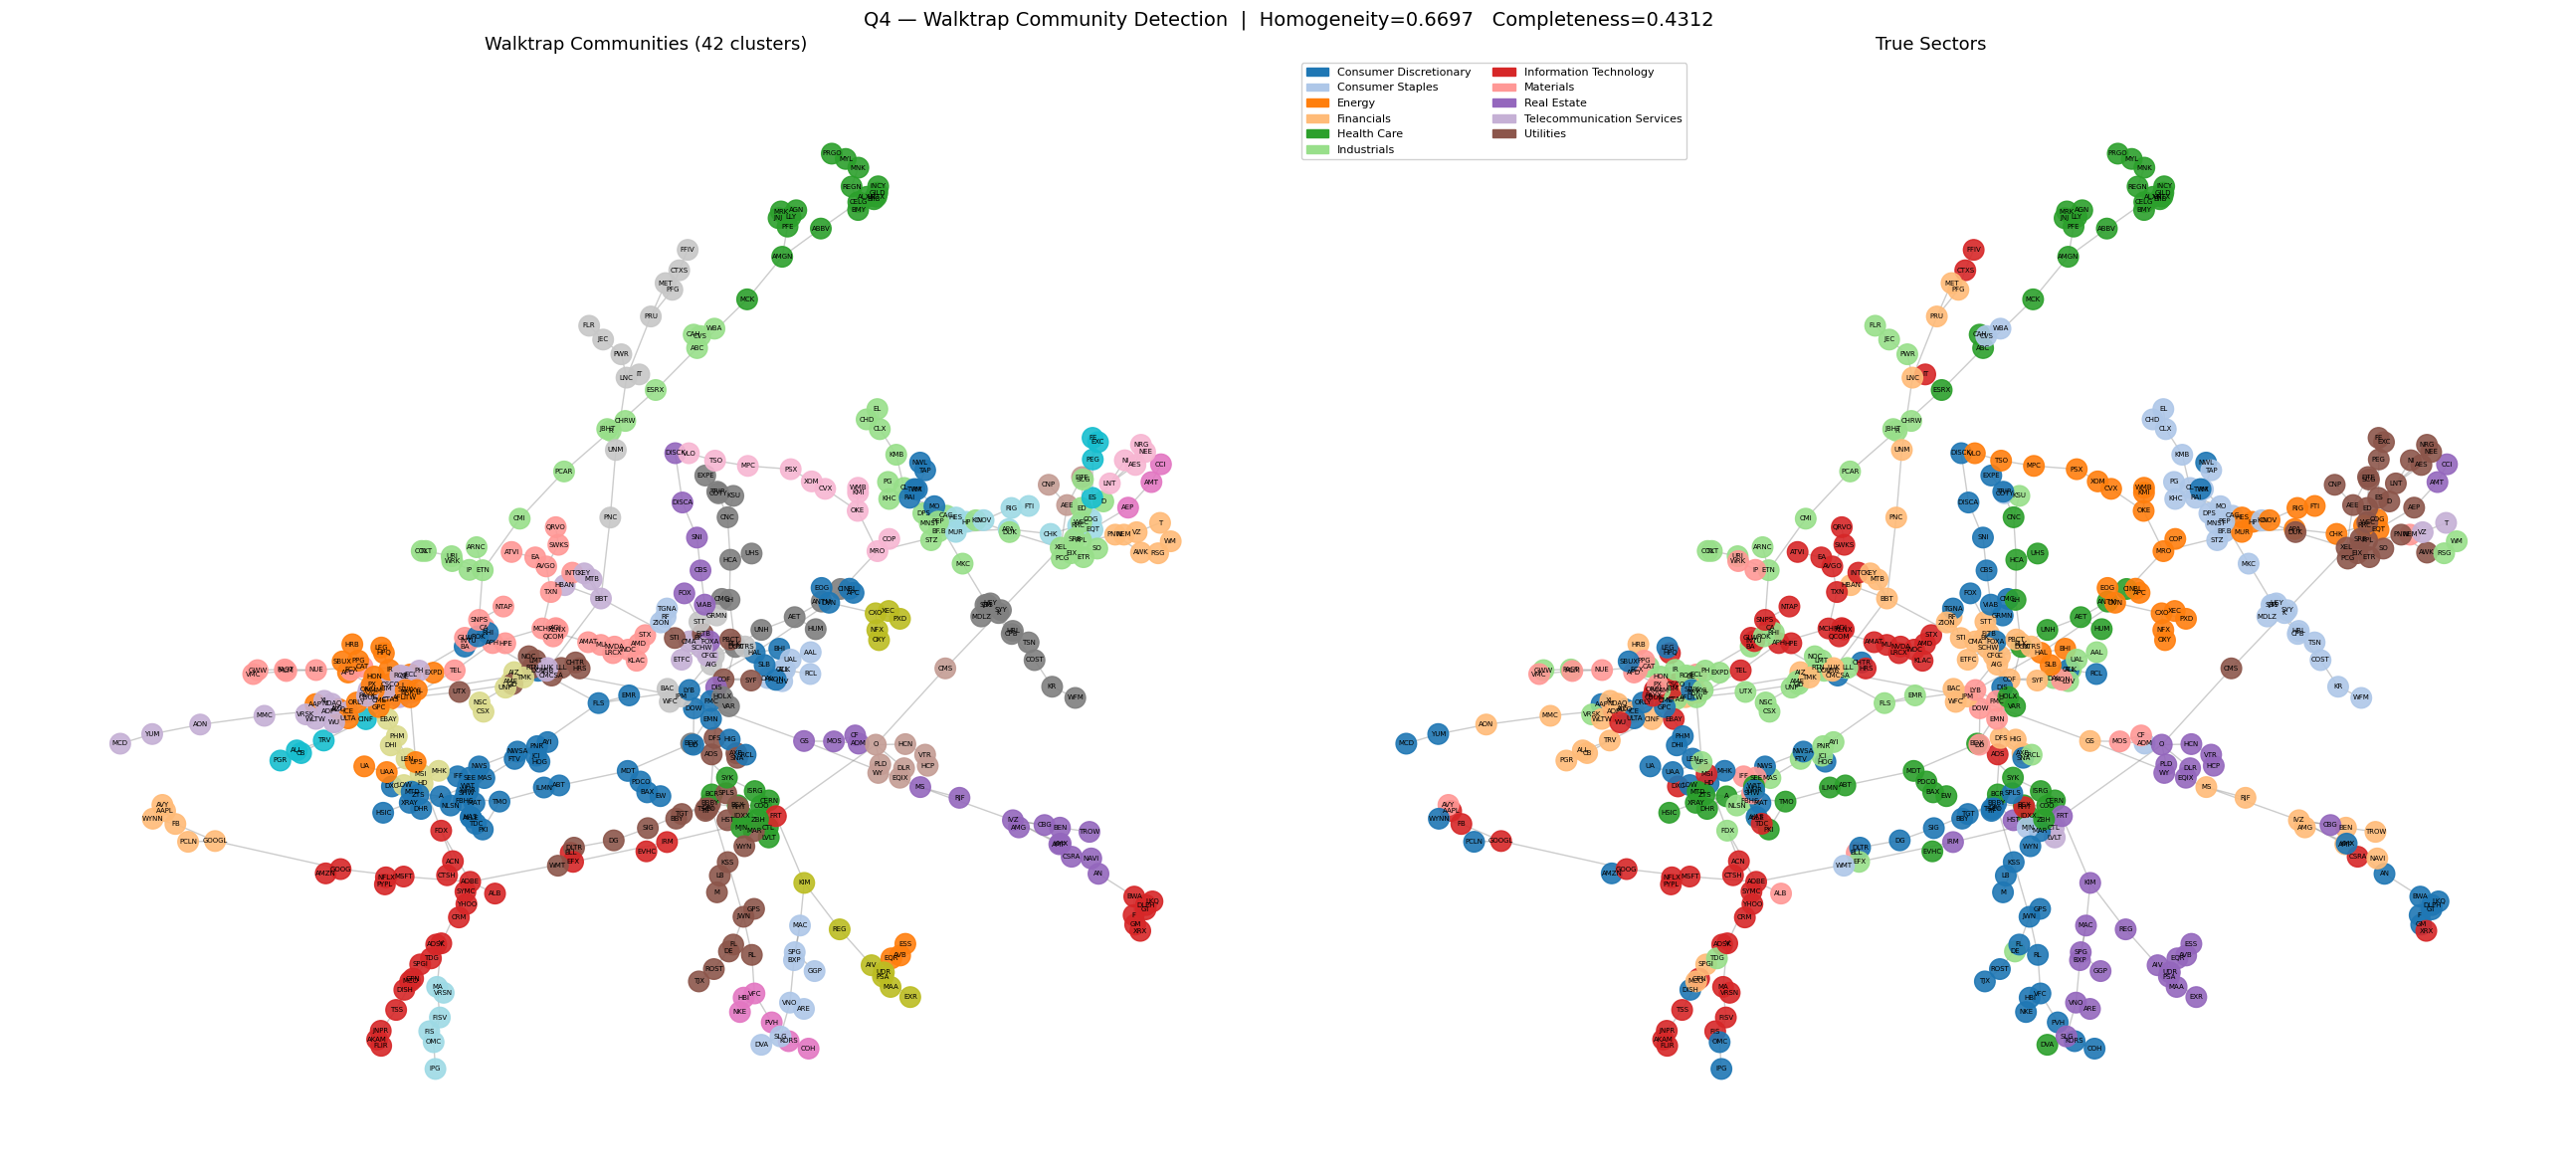

In [5]:
import igraph as ig
from sklearn.metrics.cluster import homogeneity_score, completeness_score

# ── Convert MST to igraph ────────────────────────────────────────
nodes   = list(MST.nodes())
idx     = {n: i for i, n in enumerate(nodes)}
edges   = [(idx[u], idx[v]) for u, v in MST.edges()]
weights = [MST[u][v]["weight"] for u, v in MST.edges()]

g_ig = ig.Graph()
g_ig.add_vertices(len(nodes))
g_ig.add_edges(edges)
g_ig.es["weight"] = weights
g_ig.vs["name"]   = nodes

# ── Walktrap Community Detection ────────────────────────────────
dendro     = g_ig.community_walktrap(weights="weight", steps=4)
membership = dendro.as_clustering().membership
print(f"Number of communities detected: {len(set(membership))}")

# ── Homogeneity & Completeness ──────────────────────────────────
true_labels = [sector_map.get(n, "Unknown") for n in nodes]
sec_int     = {s: i for i, s in enumerate(sorted(set(true_labels)))}
true_int    = [sec_int[s] for s in true_labels]

hom  = homogeneity_score(true_int, membership)
comp = completeness_score(true_int, membership)
print(f"Homogeneity : {hom:.4f}")
print(f"Completeness: {comp:.4f}")

# ── Plot: side by side (walktrap vs true sector) ─────────────────
comm_palette = plt.cm.tab20.colors
comm_colors  = [comm_palette[c % 20] for c in membership]
sec_colors   = [sector_color[MST.nodes[n]["sector"]] for n in MST.nodes]

fig, axes = plt.subplots(1, 2, figsize=(26, 12))

for ax, colors, title in zip(
    axes,
    [comm_colors, sec_colors],
    [f"Walktrap Communities ({len(set(membership))} clusters)",
     "True Sectors"]
):
    nx.draw_networkx_edges(MST, pos, ax=ax, edge_color="gray", alpha=0.4)
    nx.draw_networkx_nodes(MST, pos, ax=ax, node_color=colors,
                            node_size=220, alpha=0.9)
    nx.draw_networkx_labels(MST, pos, ax=ax, font_size=5)
    ax.set_title(title, fontsize=13)
    ax.axis("off")

legend_handles = [mpatches.Patch(color=sector_color[s], label=s) for s in sectors]
axes[1].legend(handles=legend_handles, loc="upper left", fontsize=8,
               ncol=2, framealpha=0.9)

fig.suptitle(
    f"Q4 — Walktrap Community Detection  |  "
    f"Homogeneity={hom:.4f}   Completeness={comp:.4f}",
    fontsize=14
)
plt.tight_layout()
plt.savefig("q4_walktrap_daily.png", dpi=150, bbox_inches="tight")
plt.show()

#Question 5

In [6]:
# ── Q5: Alpha Metric ─────────────────────────────────────────────
nodes = list(MST.nodes())
N     = len(nodes)

# Sector size count
sec_cnt = {}
for n in nodes:
    s = sector_map.get(n, "Unknown")
    sec_cnt[s] = sec_cnt.get(s, 0) + 1

sum1 = sum2 = 0.0
for v in nodes:
    sv   = sector_map.get(v, "Unknown")
    nbrs = list(MST.neighbors(v))

    # Method 1: fraction of neighbors in same sector
    if nbrs:
        same  = sum(1 for nb in nbrs if sector_map.get(nb, "Unknown") == sv)
        sum1 += same / len(nbrs)

    # Method 2: random baseline (sector prevalence in full graph)
    sum2 += sec_cnt.get(sv, 0) / N

alpha1 = sum1 / N
alpha2 = sum2 / N

print(f"alpha (MST neighbors) = {alpha1:.4f}")
print(f"alpha (random baseline) = {alpha2:.4f}")
print(f"Ratio alpha1 / alpha2   = {alpha1 / alpha2:.4f}")

alpha (MST neighbors) = 0.8009
alpha (random baseline) = 0.1146
Ratio alpha1 / alpha2   = 6.9906


#Question 6

Weekly returns: 38 weeks x 505 stocks


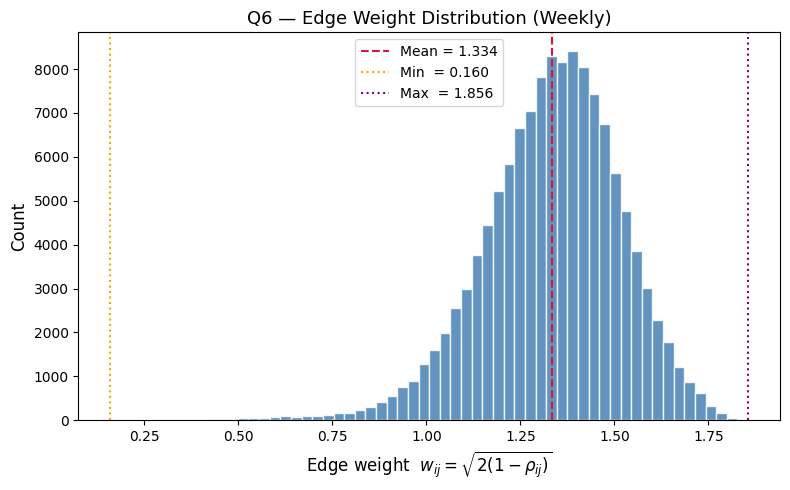

min=0.1596  max=1.8556  mean=1.3335  std=0.1839
Weekly MST: 505 nodes, 504 edges


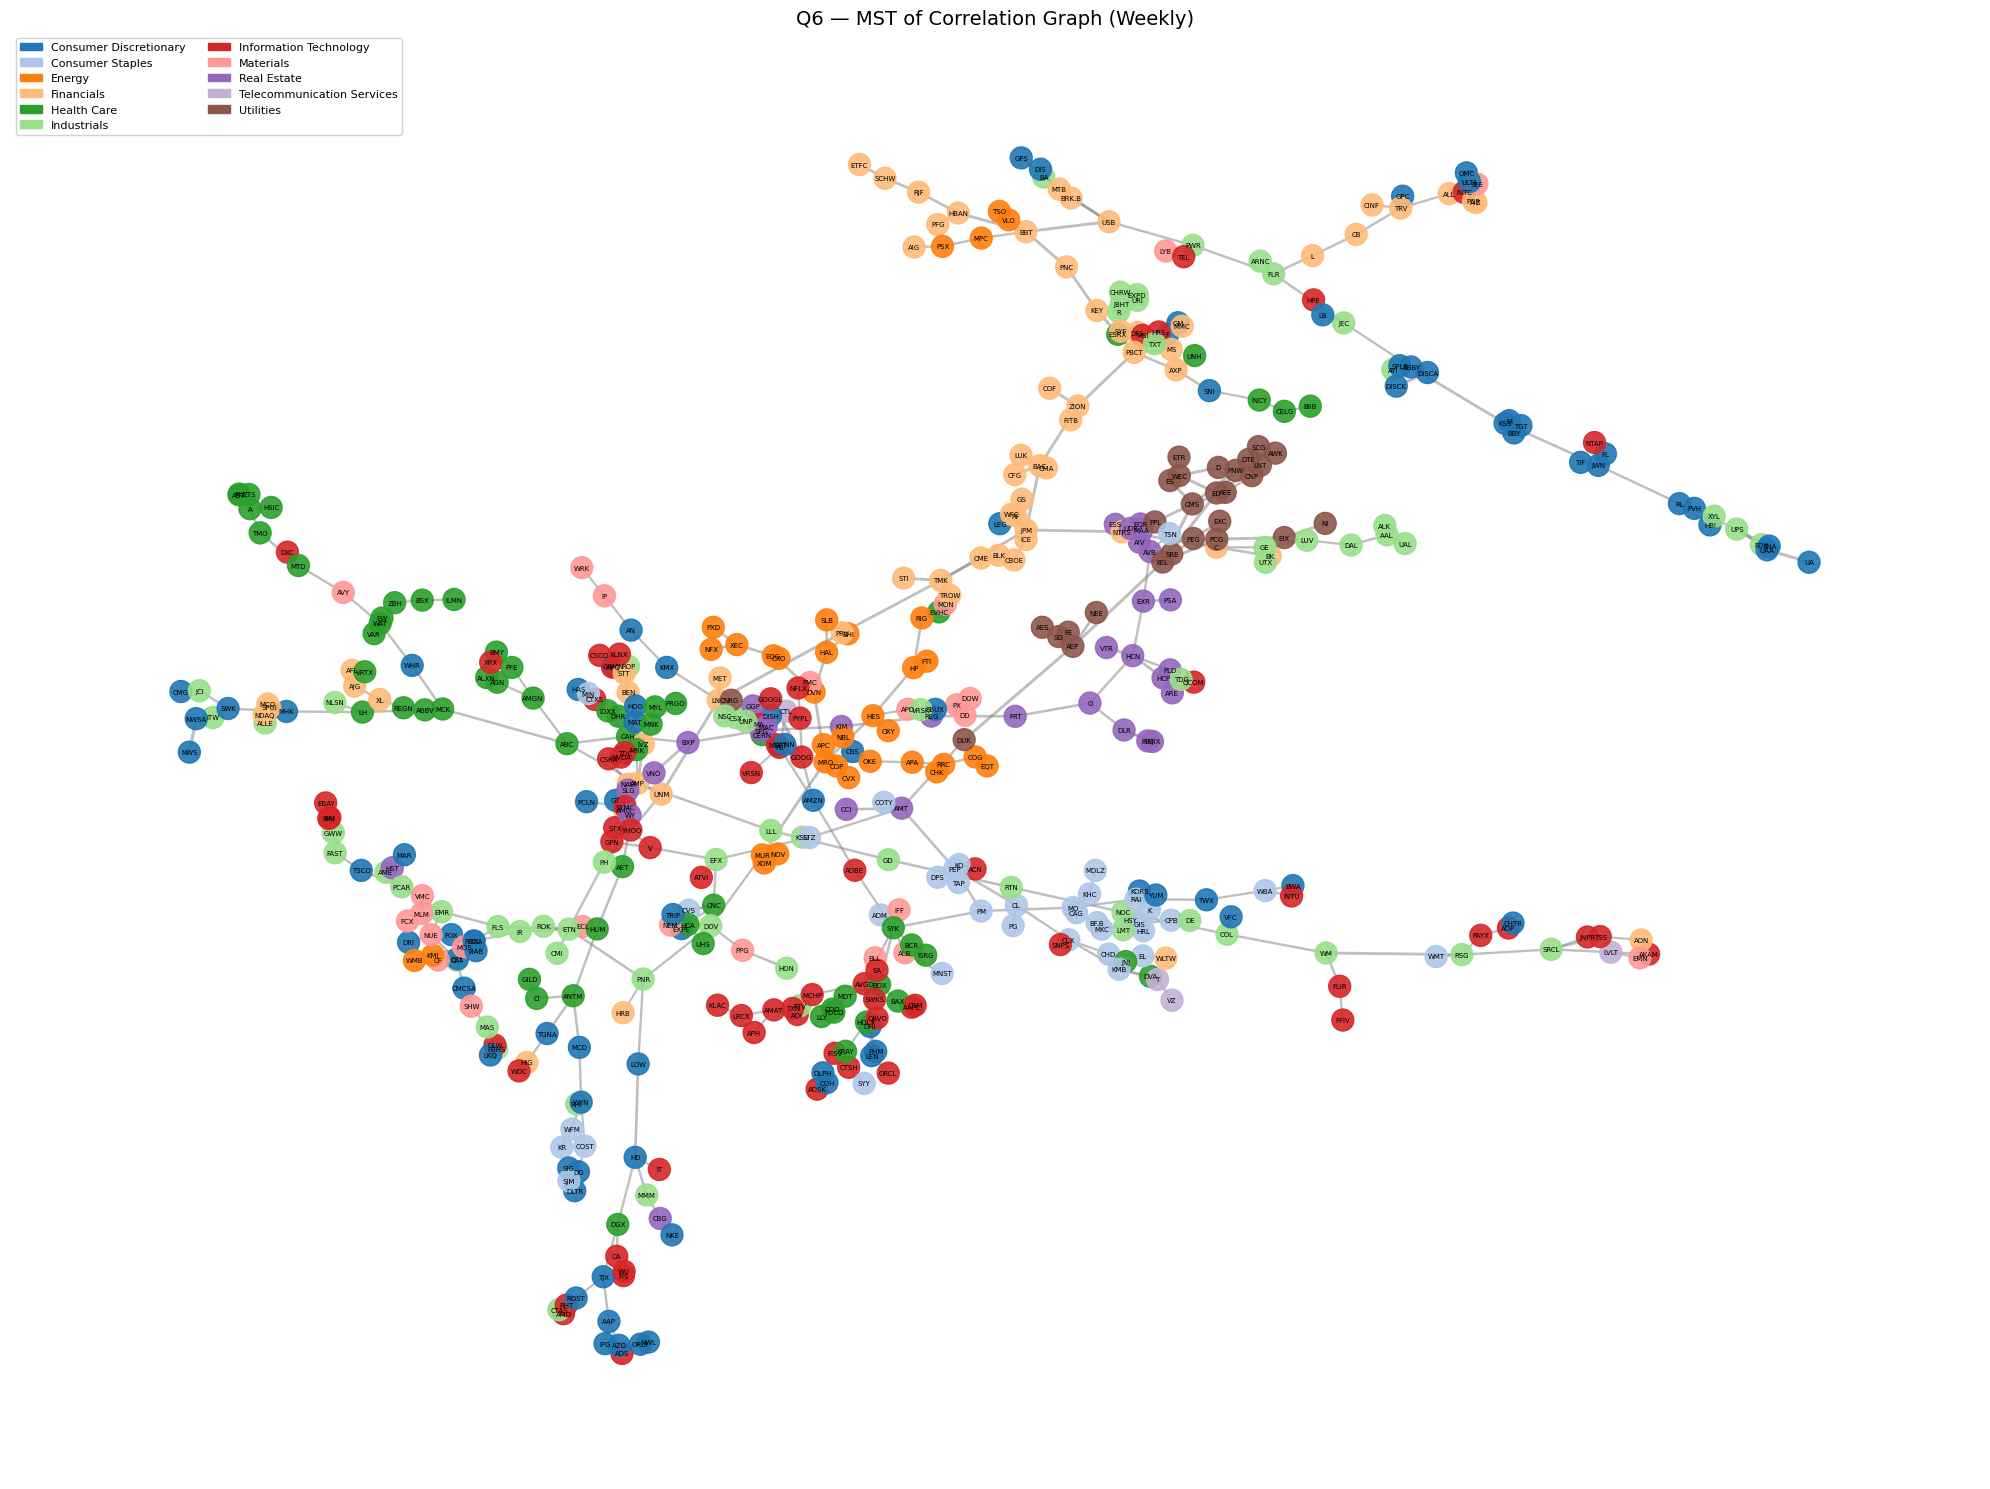

Highest degree node: AMP | Sector: Financials | Degree: 8
Weekly communities: 39
Homogeneity : 0.4825
Completeness: 0.3212


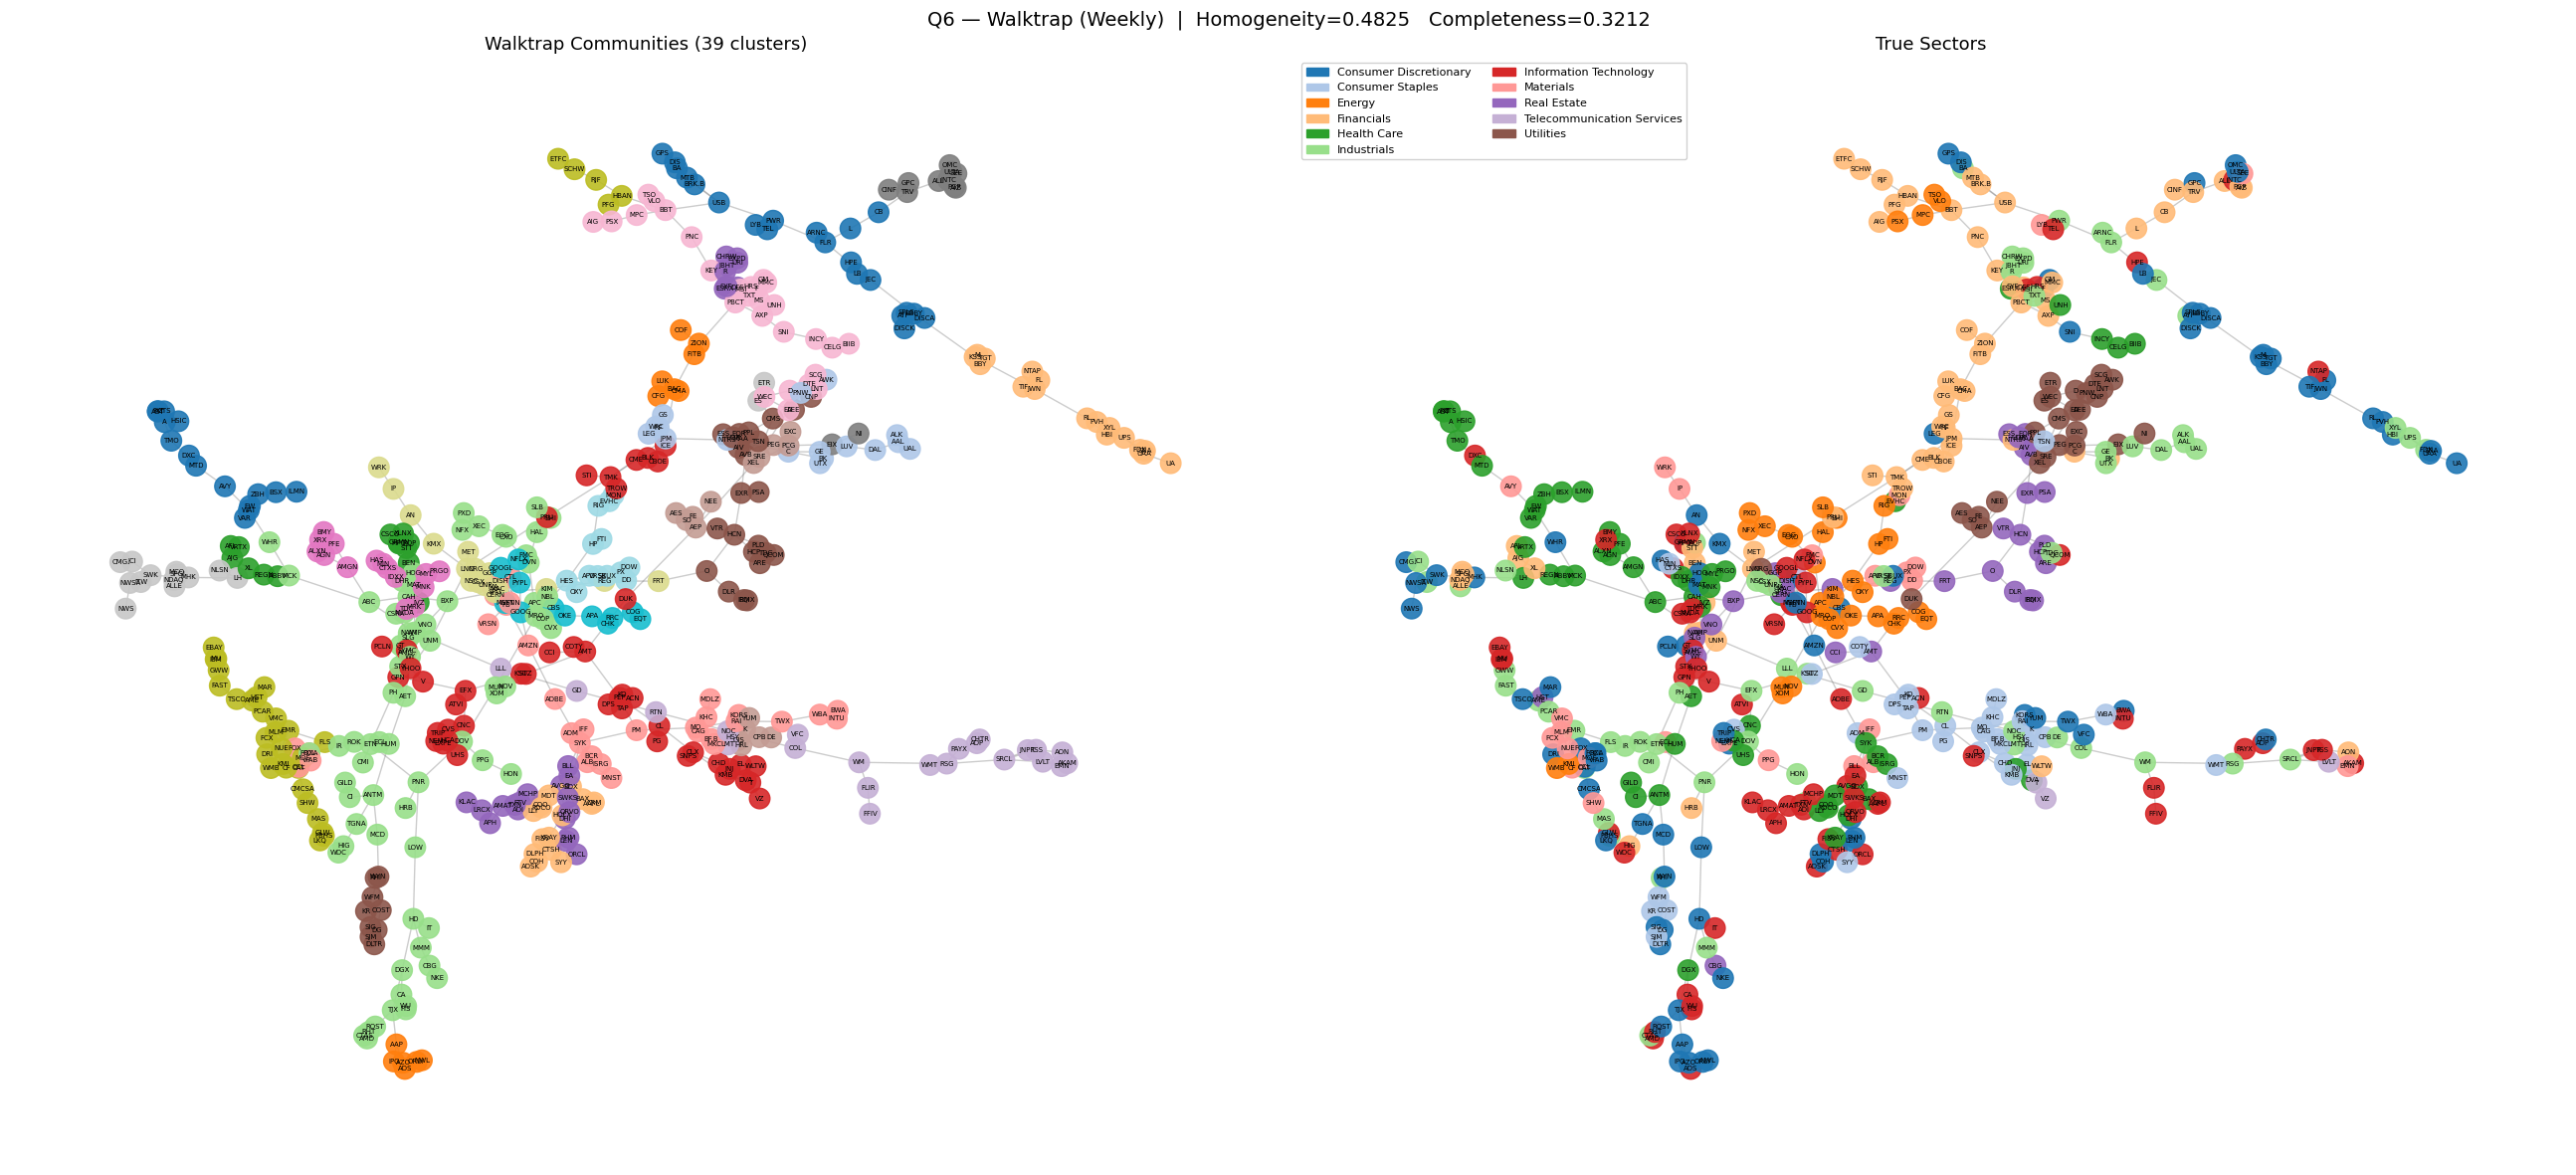

Weekly alpha (MST neighbors)  = 0.6078
Weekly alpha (random baseline) = 0.1146
Ratio alpha1 / alpha2          = 5.3050


In [7]:
# ── Weekly Log Returns ───────────────────────────────────────────
series_w = {}
for ticker in tickers:
    prices  = stock_data[ticker].set_index("Date")["Adj Close"].dropna()
    prices  = prices[prices.index.weekday == 0]   # Mondays only
    log_ret = np.log(prices / prices.shift(1)).dropna()
    series_w[ticker] = log_ret

weekly_ret = pd.DataFrame(series_w).dropna()
print(f"Weekly returns: {weekly_ret.shape[0]} weeks x {weekly_ret.shape[1]} stocks")

# ── Correlation & Edge Weights ───────────────────────────────────
weekly_corr = weekly_ret.corr(method="pearson")
weekly_w    = np.sqrt(2.0 * (1.0 - weekly_corr))

# ── Q2 (Weekly): Histogram ───────────────────────────────────────
n    = len(weekly_w)
vals = np.array([
    weekly_w.iloc[i, j]
    for i in range(n)
    for j in range(i + 1, n)
    if not np.isnan(weekly_w.iloc[i, j])
])

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(vals, bins=60, color="steelblue", edgecolor="white", alpha=0.85)
ax.axvline(vals.mean(), color="crimson", ls="--", label=f"Mean = {vals.mean():.3f}")
ax.axvline(vals.min(),  color="orange",  ls=":",  label=f"Min  = {vals.min():.3f}")
ax.axvline(vals.max(),  color="purple",  ls=":",  label=f"Max  = {vals.max():.3f}")
ax.set_xlabel(r"Edge weight  $w_{ij} = \sqrt{2(1 - \rho_{ij})}$", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title("Q6 — Edge Weight Distribution (Weekly)", fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("q6_histogram_weekly.png", dpi=150)
plt.show()
print(f"min={vals.min():.4f}  max={vals.max():.4f}  mean={vals.mean():.4f}  std={vals.std():.4f}")

# ── Q3 (Weekly): MST ─────────────────────────────────────────────
G_w = nx.Graph()
for t in tickers:
    G_w.add_node(t, sector=sector_map.get(t, "Unknown"))

cols_w = list(weekly_w.columns)
for i in range(len(cols_w)):
    for j in range(i + 1, len(cols_w)):
        w = weekly_w.iloc[i, j]
        if not np.isnan(w):
            G_w.add_edge(cols_w[i], cols_w[j], weight=float(w))

MST_w        = nx.minimum_spanning_tree(G_w, weight="weight")
pos_w        = nx.spring_layout(MST_w, seed=42, k=2.0)
node_colors_w = [sector_color[MST_w.nodes[n]["sector"]] for n in MST_w.nodes]
edge_weights_w = [MST_w[u][v]["weight"] for u, v in MST_w.edges()]
print(f"Weekly MST: {MST_w.number_of_nodes()} nodes, {MST_w.number_of_edges()} edges")

fig, ax = plt.subplots(figsize=(20, 15))
nx.draw_networkx_edges(MST_w, pos_w, ax=ax, edge_color="gray", alpha=0.5,
                        width=[max(0.3, 2.5 - w) for w in edge_weights_w])
nx.draw_networkx_nodes(MST_w, pos_w, ax=ax, node_color=node_colors_w,
                        node_size=250, alpha=0.9)
nx.draw_networkx_labels(MST_w, pos_w, ax=ax, font_size=5)
legend_handles = [mpatches.Patch(color=sector_color[s], label=s) for s in sectors]
ax.legend(handles=legend_handles, loc="upper left", fontsize=8, ncol=2, framealpha=0.9)
ax.set_title("Q6 — MST of Correlation Graph (Weekly)", fontsize=14)
ax.axis("off")
plt.tight_layout()
plt.savefig("q6_mst_weekly.png", dpi=150, bbox_inches="tight")
plt.show()

hub_w, hub_deg_w = max(MST_w.degree(), key=lambda x: x[1])
print(f"Highest degree node: {hub_w} | Sector: {sector_map.get(hub_w)} | Degree: {hub_deg_w}")

# ── Q4 (Weekly): Walktrap ────────────────────────────────────────
nodes_w   = list(MST_w.nodes())
idx_w     = {n: i for i, n in enumerate(nodes_w)}
g_ig_w    = ig.Graph()
g_ig_w.add_vertices(len(nodes_w))
g_ig_w.add_edges([(idx_w[u], idx_w[v]) for u, v in MST_w.edges()])
g_ig_w.es["weight"] = [MST_w[u][v]["weight"] for u, v in MST_w.edges()]
g_ig_w.vs["name"]   = nodes_w

dendro_w     = g_ig_w.community_walktrap(weights="weight", steps=4)
membership_w = dendro_w.as_clustering().membership
print(f"Weekly communities: {len(set(membership_w))}")

true_labels_w = [sector_map.get(n, "Unknown") for n in nodes_w]
true_int_w    = [sec_int[s] for s in true_labels_w]
hom_w  = homogeneity_score(true_int_w, membership_w)
comp_w = completeness_score(true_int_w, membership_w)
print(f"Homogeneity : {hom_w:.4f}")
print(f"Completeness: {comp_w:.4f}")

comm_colors_w = [plt.cm.tab20.colors[c % 20] for c in membership_w]
sec_colors_w  = [sector_color[MST_w.nodes[n]["sector"]] for n in MST_w.nodes]

fig, axes = plt.subplots(1, 2, figsize=(26, 12))
for ax, colors, title in zip(
    axes,
    [comm_colors_w, sec_colors_w],
    [f"Walktrap Communities ({len(set(membership_w))} clusters)", "True Sectors"]
):
    nx.draw_networkx_edges(MST_w, pos_w, ax=ax, edge_color="gray", alpha=0.4)
    nx.draw_networkx_nodes(MST_w, pos_w, ax=ax, node_color=colors,
                            node_size=220, alpha=0.9)
    nx.draw_networkx_labels(MST_w, pos_w, ax=ax, font_size=5)
    ax.set_title(title, fontsize=13)
    ax.axis("off")
axes[1].legend(handles=legend_handles, loc="upper left", fontsize=8, ncol=2, framealpha=0.9)
fig.suptitle(f"Q6 — Walktrap (Weekly)  |  Homogeneity={hom_w:.4f}   Completeness={comp_w:.4f}",
             fontsize=14)
plt.tight_layout()
plt.savefig("q6_walktrap_weekly.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Q5 (Weekly): Alpha Metric ────────────────────────────────────
sec_cnt_w = {}
for n in nodes_w:
    s = sector_map.get(n, "Unknown")
    sec_cnt_w[s] = sec_cnt_w.get(s, 0) + 1

N_w   = len(nodes_w)
sum1w = sum2w = 0.0
for v in nodes_w:
    sv   = sector_map.get(v, "Unknown")
    nbrs = list(MST_w.neighbors(v))
    if nbrs:
        same   = sum(1 for nb in nbrs if sector_map.get(nb, "Unknown") == sv)
        sum1w += same / len(nbrs)
    sum2w += sec_cnt_w.get(sv, 0) / N_w

alpha1_w = sum1w / N_w
alpha2_w = sum2w / N_w
print(f"Weekly alpha (MST neighbors)  = {alpha1_w:.4f}")
print(f"Weekly alpha (random baseline) = {alpha2_w:.4f}")
print(f"Ratio alpha1 / alpha2          = {alpha1_w / alpha2_w:.4f}")

#Question 7

Monthly returns: 6 months x 505 stocks


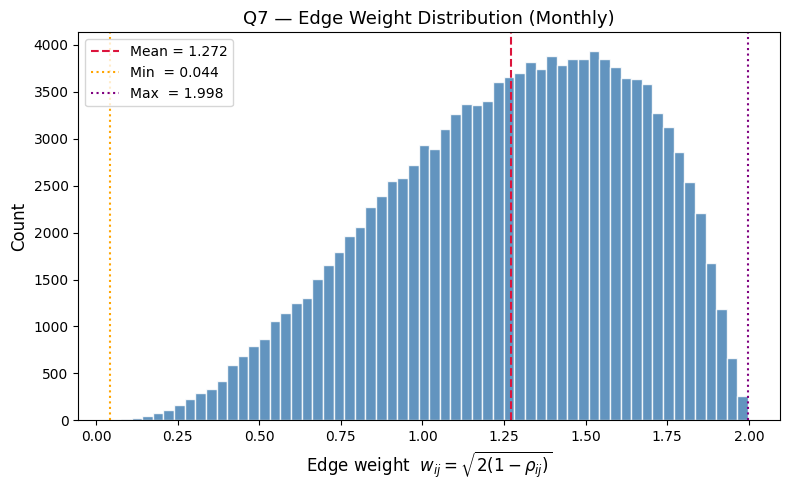

min=0.0435  max=1.9976  mean=1.2720  std=0.3836
Monthly MST: 505 nodes, 504 edges


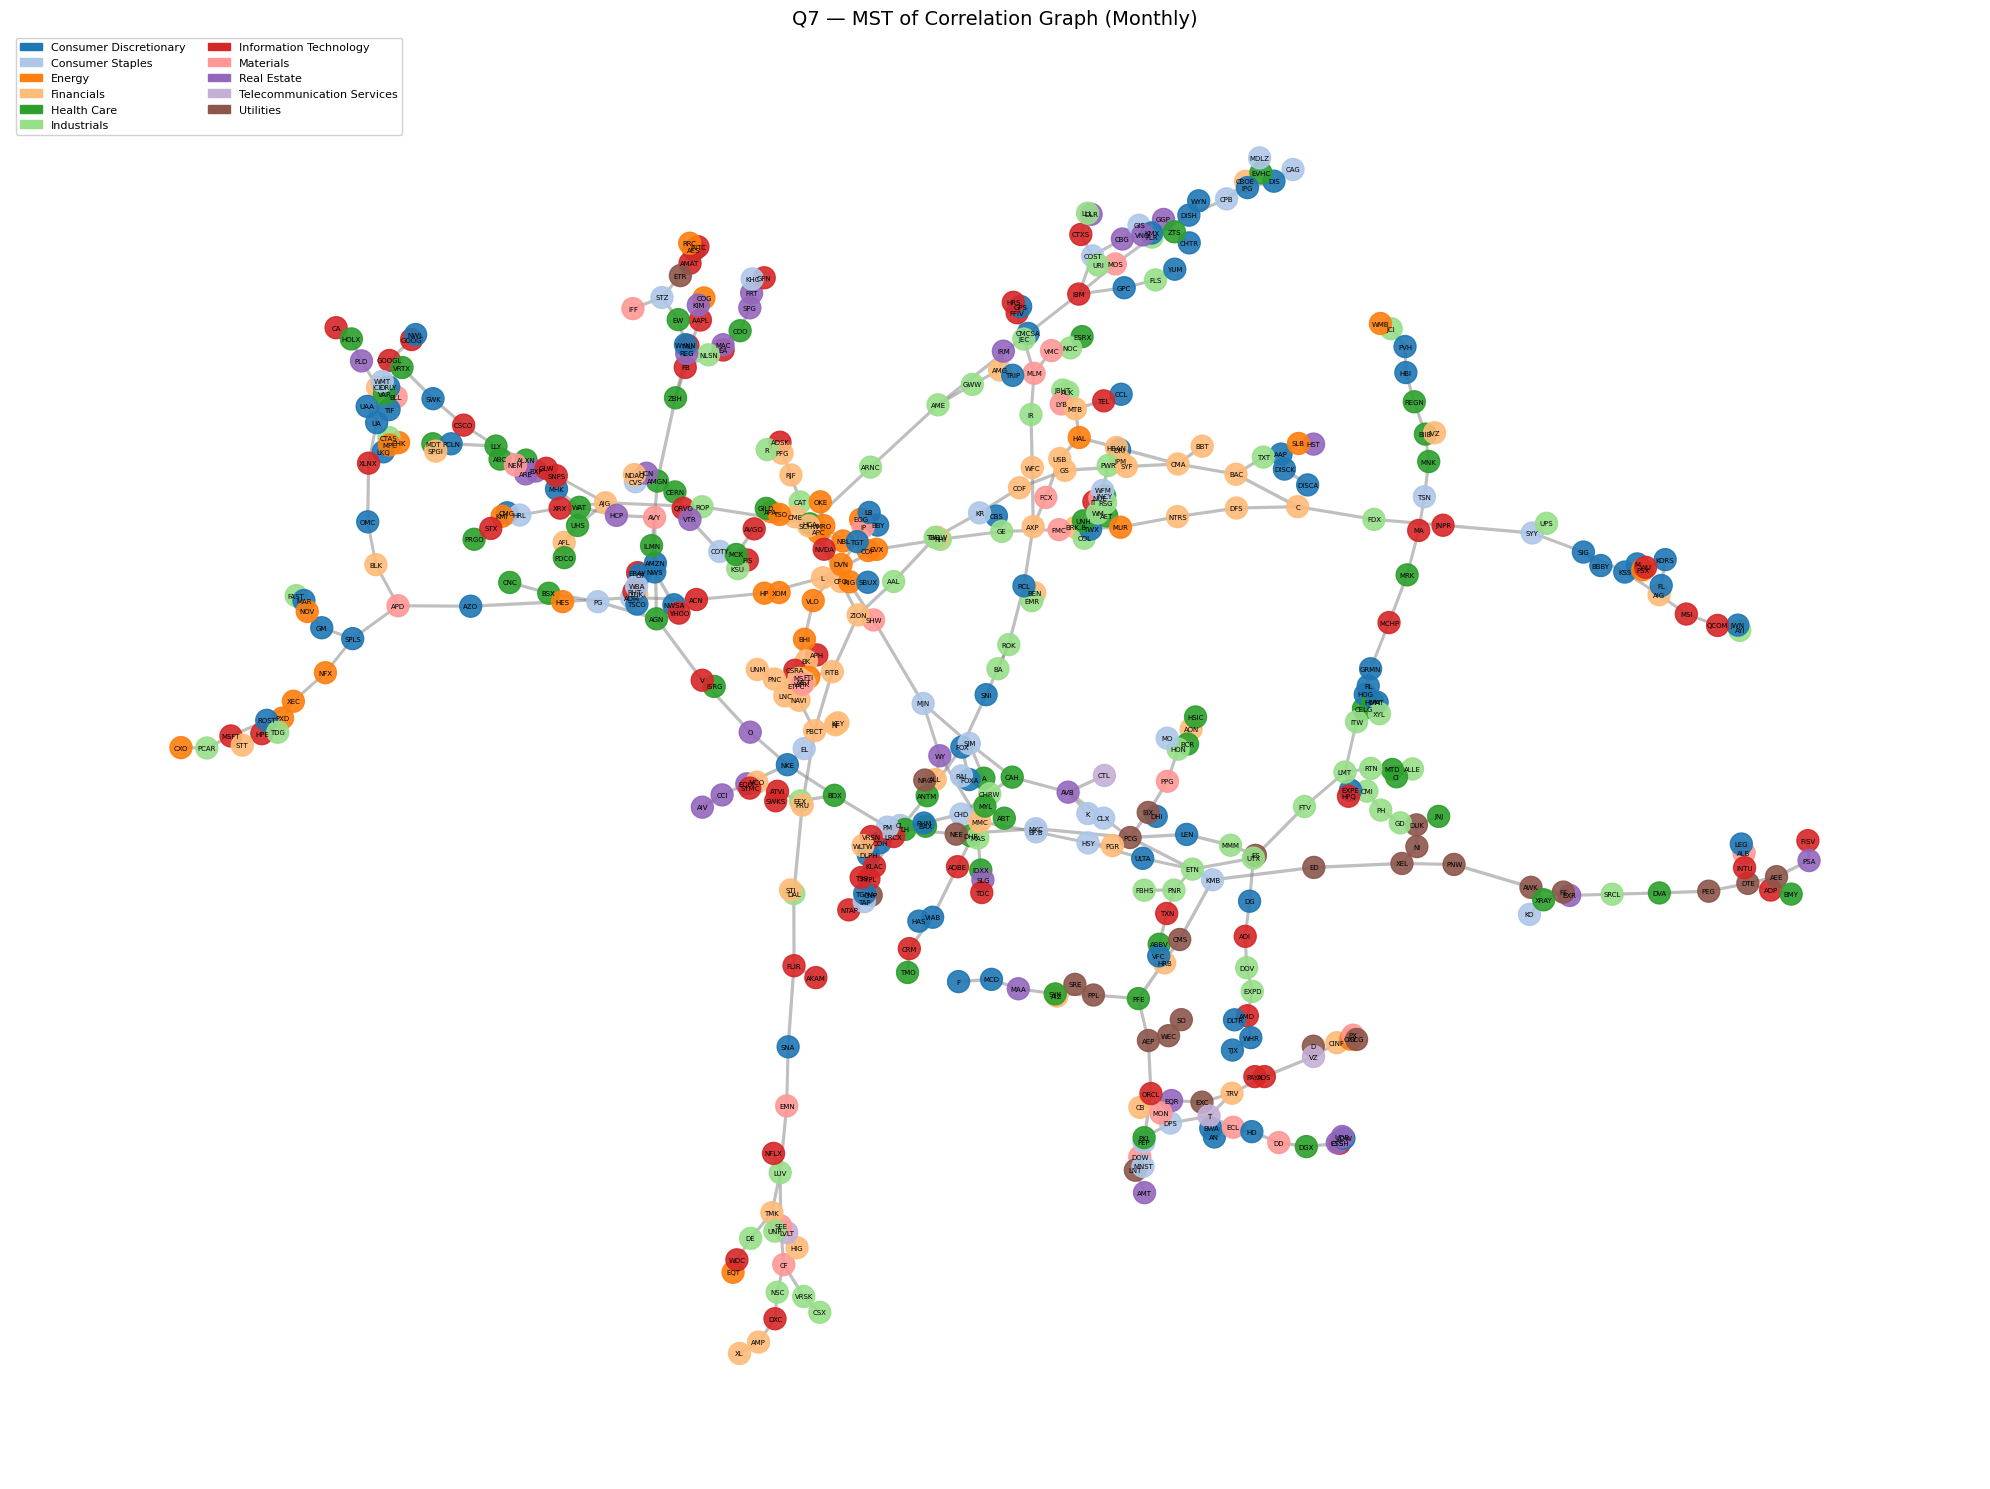

Highest degree node: LMT | Sector: Industrials | Degree: 5
Monthly communities: 47
Homogeneity : 0.3064
Completeness: 0.1925


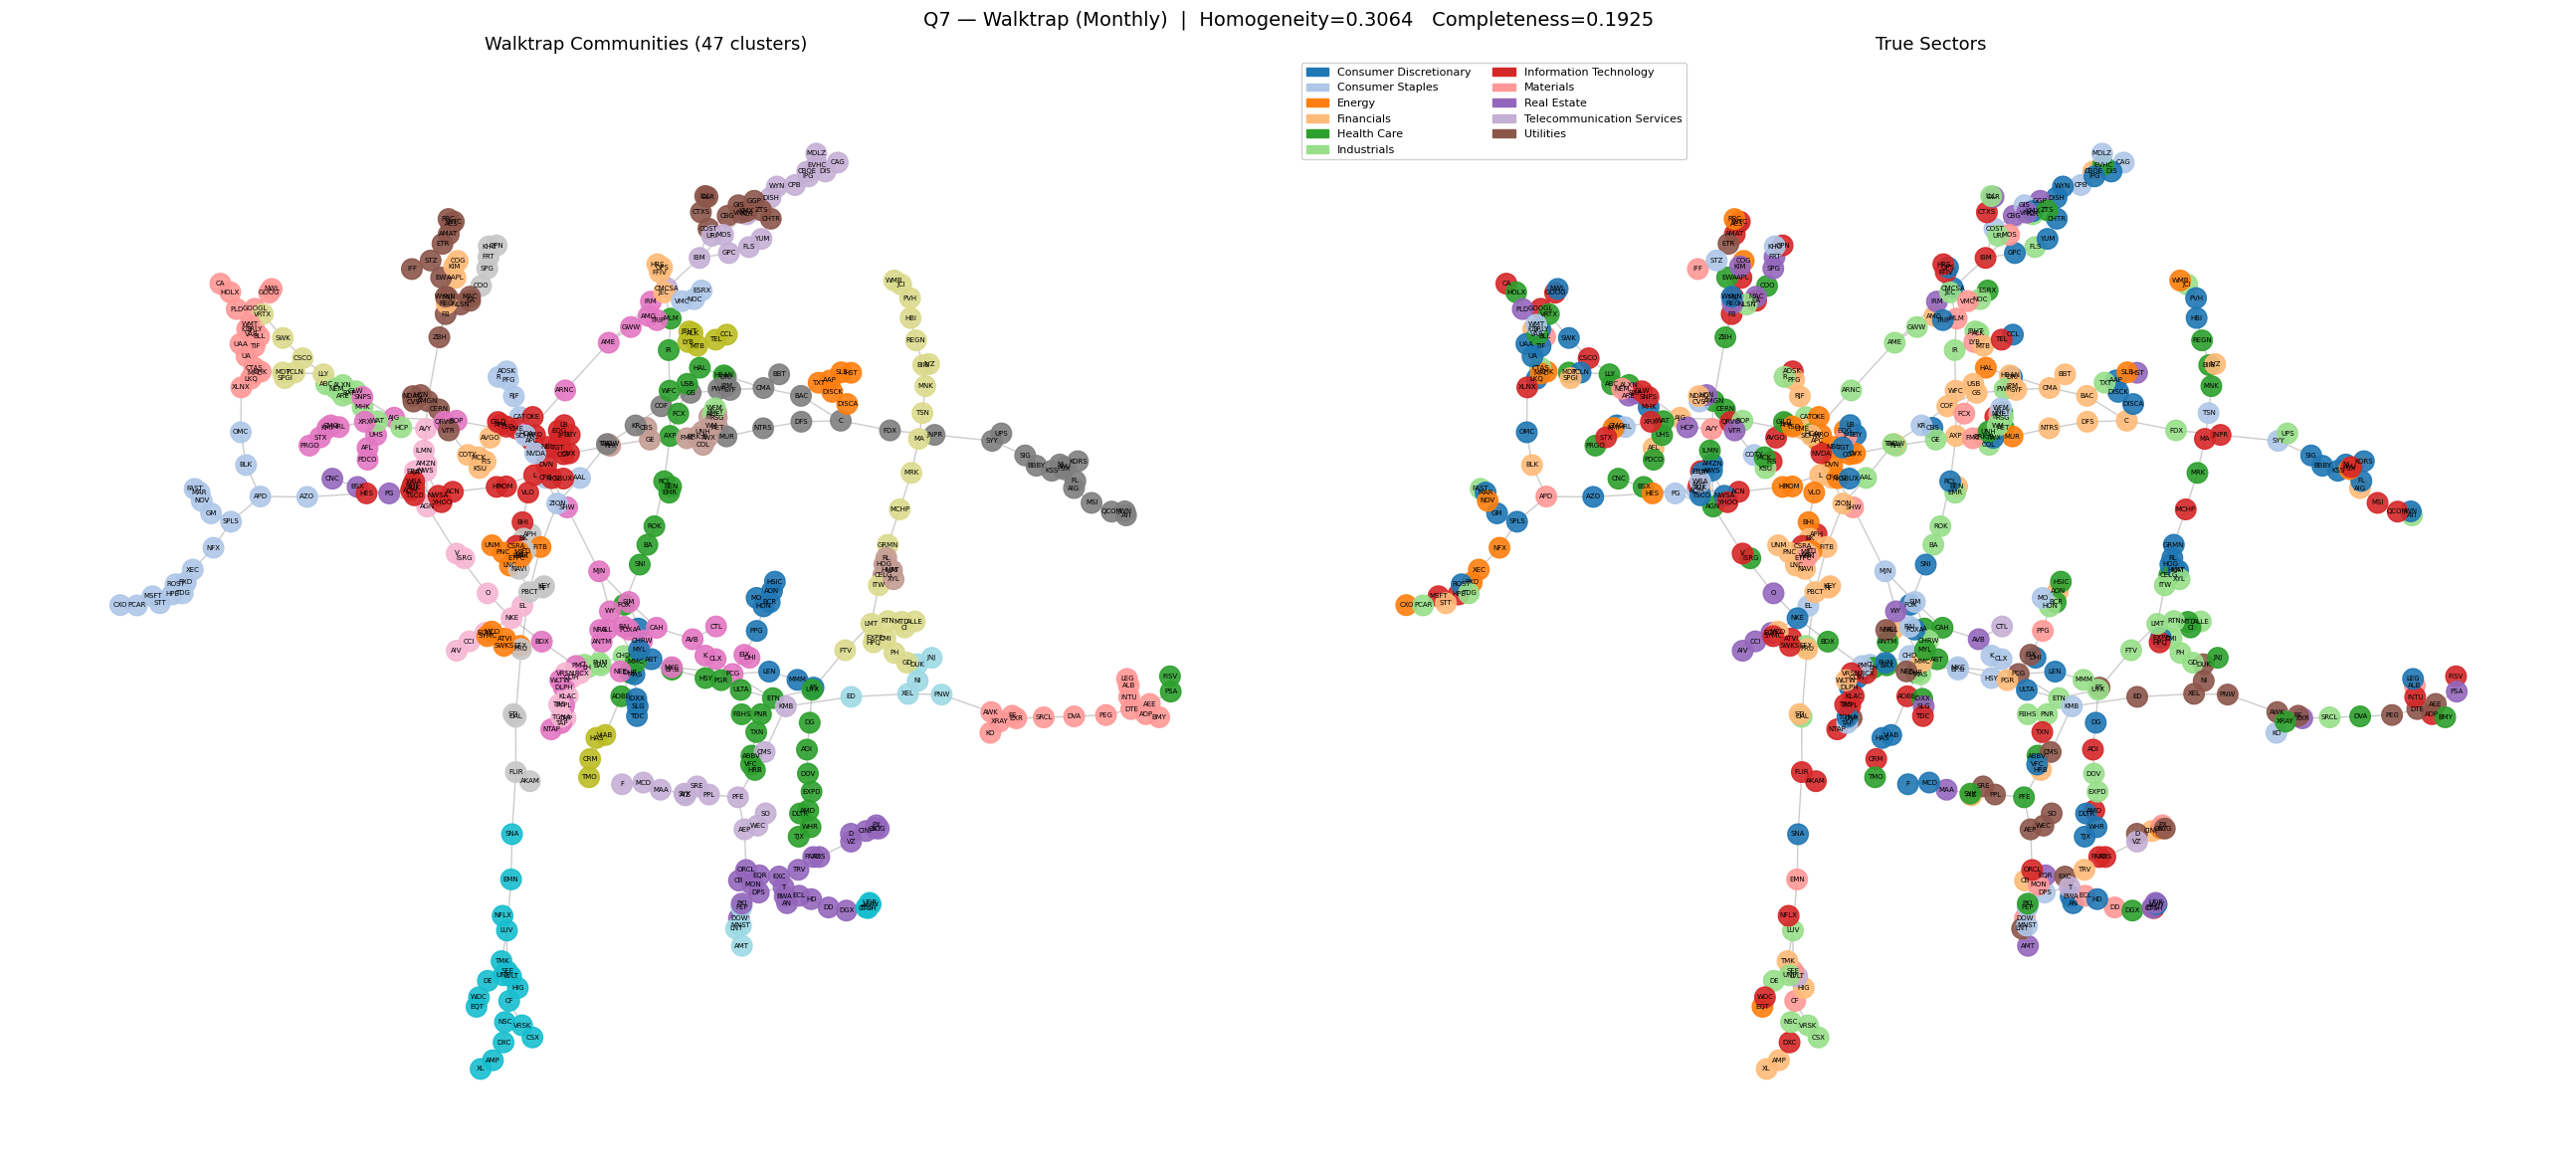

Monthly alpha (MST neighbors)  = 0.2238
Monthly alpha (random baseline) = 0.1146
Ratio alpha1 / alpha2           = 1.9531


In [8]:
# ── Monthly Log Returns ──────────────────────────────────────────
series_m = {}
for ticker in tickers:
    prices  = stock_data[ticker].set_index("Date")["Adj Close"].dropna()
    prices  = prices[prices.index.day == 15]      # 15th of each month only
    log_ret = np.log(prices / prices.shift(1)).dropna()
    series_m[ticker] = log_ret

monthly_ret = pd.DataFrame(series_m).dropna()
print(f"Monthly returns: {monthly_ret.shape[0]} months x {monthly_ret.shape[1]} stocks")

# ── Correlation & Edge Weights ───────────────────────────────────
monthly_corr = monthly_ret.corr(method="pearson")
monthly_w    = np.sqrt(2.0 * (1.0 - monthly_corr))

# ── Q2 (Monthly): Histogram ──────────────────────────────────────
n    = len(monthly_w)
vals = np.array([
    monthly_w.iloc[i, j]
    for i in range(n)
    for j in range(i + 1, n)
    if not np.isnan(monthly_w.iloc[i, j])
])

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(vals, bins=60, color="steelblue", edgecolor="white", alpha=0.85)
ax.axvline(vals.mean(), color="crimson", ls="--", label=f"Mean = {vals.mean():.3f}")
ax.axvline(vals.min(),  color="orange",  ls=":",  label=f"Min  = {vals.min():.3f}")
ax.axvline(vals.max(),  color="purple",  ls=":",  label=f"Max  = {vals.max():.3f}")
ax.set_xlabel(r"Edge weight  $w_{ij} = \sqrt{2(1 - \rho_{ij})}$", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title("Q7 — Edge Weight Distribution (Monthly)", fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("q7_histogram_monthly.png", dpi=150)
plt.show()
print(f"min={vals.min():.4f}  max={vals.max():.4f}  mean={vals.mean():.4f}  std={vals.std():.4f}")

# ── Q3 (Monthly): MST ────────────────────────────────────────────
G_m = nx.Graph()
for t in tickers:
    G_m.add_node(t, sector=sector_map.get(t, "Unknown"))

cols_m = list(monthly_w.columns)
for i in range(len(cols_m)):
    for j in range(i + 1, len(cols_m)):
        w = monthly_w.iloc[i, j]
        if not np.isnan(w):
            G_m.add_edge(cols_m[i], cols_m[j], weight=float(w))

MST_m         = nx.minimum_spanning_tree(G_m, weight="weight")
pos_m         = nx.spring_layout(MST_m, seed=42, k=2.0)
node_colors_m = [sector_color[MST_m.nodes[n]["sector"]] for n in MST_m.nodes]
edge_weights_m = [MST_m[u][v]["weight"] for u, v in MST_m.edges()]
print(f"Monthly MST: {MST_m.number_of_nodes()} nodes, {MST_m.number_of_edges()} edges")

fig, ax = plt.subplots(figsize=(20, 15))
nx.draw_networkx_edges(MST_m, pos_m, ax=ax, edge_color="gray", alpha=0.5,
                        width=[max(0.3, 2.5 - w) for w in edge_weights_m])
nx.draw_networkx_nodes(MST_m, pos_m, ax=ax, node_color=node_colors_m,
                        node_size=250, alpha=0.9)
nx.draw_networkx_labels(MST_m, pos_m, ax=ax, font_size=5)
legend_handles = [mpatches.Patch(color=sector_color[s], label=s) for s in sectors]
ax.legend(handles=legend_handles, loc="upper left", fontsize=8, ncol=2, framealpha=0.9)
ax.set_title("Q7 — MST of Correlation Graph (Monthly)", fontsize=14)
ax.axis("off")
plt.tight_layout()
plt.savefig("q7_mst_monthly.png", dpi=150, bbox_inches="tight")
plt.show()

hub_m, hub_deg_m = max(MST_m.degree(), key=lambda x: x[1])
print(f"Highest degree node: {hub_m} | Sector: {sector_map.get(hub_m)} | Degree: {hub_deg_m}")

# ── Q4 (Monthly): Walktrap ───────────────────────────────────────
nodes_m   = list(MST_m.nodes())
idx_m     = {n: i for i, n in enumerate(nodes_m)}
g_ig_m    = ig.Graph()
g_ig_m.add_vertices(len(nodes_m))
g_ig_m.add_edges([(idx_m[u], idx_m[v]) for u, v in MST_m.edges()])
g_ig_m.es["weight"] = [MST_m[u][v]["weight"] for u, v in MST_m.edges()]
g_ig_m.vs["name"]   = nodes_m

dendro_m     = g_ig_m.community_walktrap(weights="weight", steps=4)
membership_m = dendro_m.as_clustering().membership
print(f"Monthly communities: {len(set(membership_m))}")

true_labels_m = [sector_map.get(n, "Unknown") for n in nodes_m]
true_int_m    = [sec_int[s] for s in true_labels_m]
hom_m  = homogeneity_score(true_int_m, membership_m)
comp_m = completeness_score(true_int_m, membership_m)
print(f"Homogeneity : {hom_m:.4f}")
print(f"Completeness: {comp_m:.4f}")

comm_colors_m = [plt.cm.tab20.colors[c % 20] for c in membership_m]
sec_colors_m  = [sector_color[MST_m.nodes[n]["sector"]] for n in MST_m.nodes]

fig, axes = plt.subplots(1, 2, figsize=(26, 12))
for ax, colors, title in zip(
    axes,
    [comm_colors_m, sec_colors_m],
    [f"Walktrap Communities ({len(set(membership_m))} clusters)", "True Sectors"]
):
    nx.draw_networkx_edges(MST_m, pos_m, ax=ax, edge_color="gray", alpha=0.4)
    nx.draw_networkx_nodes(MST_m, pos_m, ax=ax, node_color=colors,
                            node_size=220, alpha=0.9)
    nx.draw_networkx_labels(MST_m, pos_m, ax=ax, font_size=5)
    ax.set_title(title, fontsize=13)
    ax.axis("off")
axes[1].legend(handles=legend_handles, loc="upper left", fontsize=8, ncol=2, framealpha=0.9)
fig.suptitle(f"Q7 — Walktrap (Monthly)  |  Homogeneity={hom_m:.4f}   Completeness={comp_m:.4f}",
             fontsize=14)
plt.tight_layout()
plt.savefig("q7_walktrap_monthly.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Q5 (Monthly): Alpha Metric ───────────────────────────────────
sec_cnt_m = {}
for n in nodes_m:
    s = sector_map.get(n, "Unknown")
    sec_cnt_m[s] = sec_cnt_m.get(s, 0) + 1

N_m   = len(nodes_m)
sum1m = sum2m = 0.0
for v in nodes_m:
    sv   = sector_map.get(v, "Unknown")
    nbrs = list(MST_m.neighbors(v))
    if nbrs:
        same   = sum(1 for nb in nbrs if sector_map.get(nb, "Unknown") == sv)
        sum1m += same / len(nbrs)
    sum2m += sec_cnt_m.get(sv, 0) / N_m

alpha1_m = sum1m / N_m
alpha2_m = sum2m / N_m
print(f"Monthly alpha (MST neighbors)  = {alpha1_m:.4f}")
print(f"Monthly alpha (random baseline) = {alpha2_m:.4f}")
print(f"Ratio alpha1 / alpha2           = {alpha1_m / alpha2_m:.4f}")